In [7]:
import sys
import os

# Move one directory up (to project root)
project_root = os.path.abspath("..")
sys.path.append(project_root)

print("Added to PYTHONPATH:", project_root)


Added to PYTHONPATH: /vols/cms/mm1221/Independent/validation_new


In [8]:
import pandas as pd

# --- File paths ---
contrastive_path = "../CL.csv"
oc_path          = "../OC.csv"

# --- Load CSV files ---
df_contrastive = pd.read_csv(contrastive_path)
df_oc          = pd.read_csv(oc_path)

# --- Print basic info and first few rows ---
print("=== Contrastive Learning DF (first 5 rows) ===")
display(df_contrastive.head(50))

print("\n=== Object Condensation DF (first 5 rows) ===")
display(df_oc.head(20))

print("\nContrastive shape:", df_contrastive.shape)
print("OC shape:", df_oc.shape)


=== Contrastive Learning DF (first 5 rows) ===


,event_id,cp_id,reco_id,cp_energy,reco_energy,shared_energy,RtS
0,0,0,0,457.040470,787.81030,457.040470,0.372573
1,0,1,0,330.769840,787.81030,330.769840,0.627427
2,1,0,0,221.950200,621.86340,221.950200,0.790964
3,1,1,0,399.913270,621.86340,399.913270,0.209036
4,2,0,0,257.841900,261.39710,256.961600,0.000689
5,2,0,1,257.841900,159.87889,0.880297,0.999771
6,2,1,0,163.434080,261.39710,4.435482,0.999311
7,2,1,1,163.434080,159.87889,158.998600,0.000229
8,3,0,0,125.348520,128.91667,123.488720,0.004100
9,3,0,1,125.348520,295.16202,1.859791,0.999916



=== Object Condensation DF (first 5 rows) ===


,event_id,cp_id,reco_id,cp_energy,reco_energy,shared_energy,RtS
0,0,0,0,94548.420,92948.640,92075.7400,0.000138
1,0,0,1,94548.420,70026.470,2472.6804,0.998206
2,0,1,0,68426.700,92948.640,872.9055,0.999862
3,0,1,1,68426.700,70026.470,67553.7900,0.001794
4,1,0,0,45915.060,46649.867,44147.4530,0.003412
5,1,0,1,45915.060,81995.640,1767.6023,0.999428
6,1,1,0,82730.445,46649.867,2502.4140,0.996588
7,1,1,1,82730.445,81995.640,80228.0500,0.000572
8,2,0,0,53340.010,33610.100,552.9626,0.999250
9,2,0,1,53340.010,53539.684,52787.0470,0.000628



Contrastive shape: (3204, 7)
OC shape: (4054, 7)


In [9]:
from src.metrics.calculations import calc_ratio

print("=== Number Ratio (Reco / CP) ===\n")

ratio_contrastive = calc_ratio(df_contrastive)
ratio_oc          = calc_ratio(df_oc)

print(f"Contrastive ratio : {ratio_contrastive:.3f}")
print(f"Object Condensation ratio : {ratio_oc:.3f}")


=== Number Ratio (Reco / CP) ===

Contrastive ratio : 0.800
Object Condensation ratio : 1.012


In [19]:
import numpy as np
import matplotlib.pyplot as plt

from src.metrics.calculations import calc_purity, calc_efficiency

# 1) Efficiency binning

all_cp = np.concatenate([
    df_contrastive["cp_energy"].values,
    df_oc["cp_energy"].values,
])

n_bins = 10
cp_bins = np.linspace(all_cp.min(), all_cp.max(), n_bins + 1)
cp_bin_centers = 0.5 * (cp_bins[:-1] + cp_bins[1:])

eff_contrastive = []
eff_oc = []

for i in range(n_bins):
    low, high = cp_bins[i], cp_bins[i + 1]

    df_c_bin = df_contrastive[(df_contrastive["cp_energy"] >= low) &
                               (df_contrastive["cp_energy"] < high)]
    df_oc_bin = df_oc[(df_oc["cp_energy"] >= low) &
                      (df_oc["cp_energy"] < high)]

    eff_contrastive.append(calc_efficiency(df_c_bin, threshold=0.5) if len(df_c_bin) else np.nan)
    eff_oc.append(calc_efficiency(df_oc_bin, threshold=0.5) if len(df_oc_bin) else np.nan)


# 2) Purity binning restricted to 10–100 GeV reco_energy

LOW = 100    # 10 GeV in MeV
HIGH = 1000  # 100 GeV in MeV

# mask to only use events in this physical range
df_c_restricted = df_contrastive[(df_contrastive["reco_energy"] >= LOW) &
                                 (df_contrastive["reco_energy"] <= HIGH)]
df_oc_restricted = df_oc[(df_oc["reco_energy"] >= LOW) &
                         (df_oc["reco_energy"] <= HIGH)]

# choose bins **within this restricted range only**
reco_bins = np.linspace(LOW, HIGH, n_bins + 1)
reco_bin_centers = 0.5 * (reco_bins[:-1] + reco_bins[1:])

purity_contrastive = []
purity_oc = []

for i in range(n_bins):
    low, high = reco_bins[i], reco_bins[i + 1]

    df_c_bin = df_c_restricted[(df_c_restricted["reco_energy"] >= low) &
                               (df_c_restricted["reco_energy"] < high)]
    df_oc_bin = df_oc_restricted[(df_oc_restricted["reco_energy"] >= low) &
                                 (df_oc_restricted["reco_energy"] < high)]

    purity_contrastive.append(calc_purity(df_c_bin, threshold=0.2) if len(df_c_bin) else np.nan)
    purity_oc.append(calc_purity(df_oc_bin, threshold=0.2) if len(df_oc_bin) else np.nan)


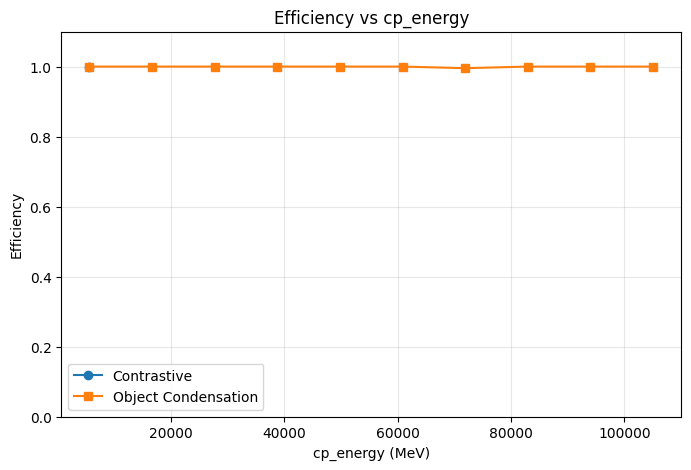

In [20]:
plt.figure(figsize=(8, 5))

plt.plot(cp_bin_centers, eff_contrastive, "o-", label="Contrastive")
plt.plot(cp_bin_centers, eff_oc, "s-", label="Object Condensation")

plt.xlabel("cp_energy (MeV)")
plt.ylabel("Efficiency")
plt.title("Efficiency vs cp_energy")
plt.ylim(0,1.1)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


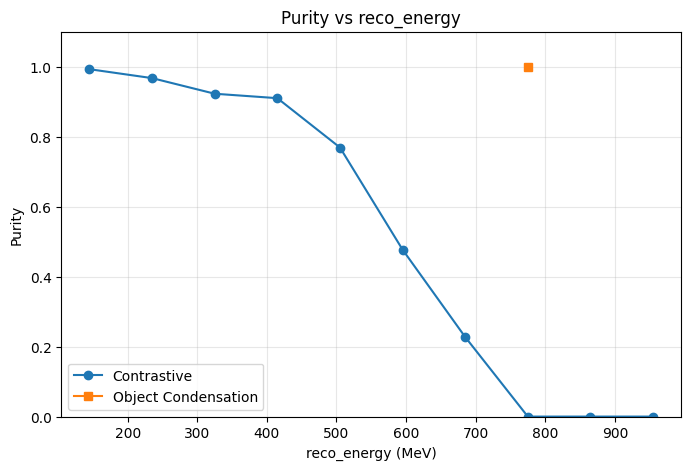

In [21]:
plt.figure(figsize=(8, 5))

plt.plot(reco_bin_centers, purity_contrastive, "o-", label="Contrastive")
plt.plot(reco_bin_centers, purity_oc, "s-", label="Object Condensation")

plt.xlabel("reco_energy (MeV)")
plt.ylabel("Purity")
plt.title("Purity vs reco_energy")
plt.ylim(0,1.1)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


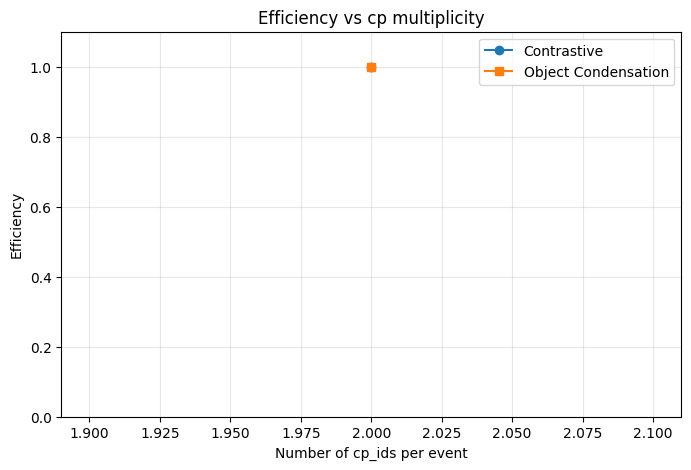

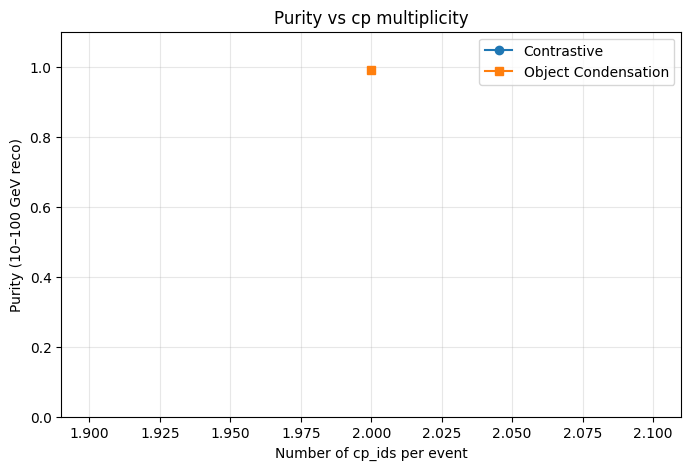

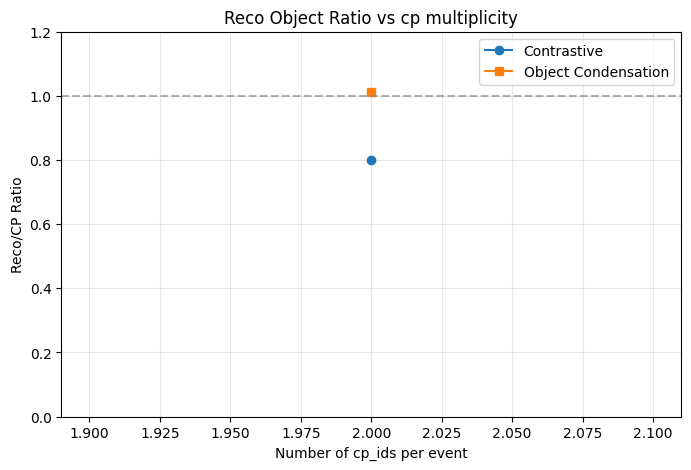

In [18]:
import numpy as np
import matplotlib.pyplot as plt

from src.metrics.calculations import calc_purity, calc_efficiency, calc_ratio

# -------------------------------------------------
# 0) Compute cp multiplicity per event
# -------------------------------------------------

cp_per_event = (
    df_contrastive[["event_id", "cp_id"]]
    .drop_duplicates()
    .groupby("event_id")["cp_id"]
    .nunique()
)

multiplicities = np.sort(cp_per_event.unique())

# -------------------------------------------------
# 1) Efficiency vs multiplicity
# -------------------------------------------------

eff_contrastive = []
eff_oc = []

for m in multiplicities:
    event_ids_m = cp_per_event.index[cp_per_event == m]

    df_c_m = df_contrastive[df_contrastive["event_id"].isin(event_ids_m)]
    df_oc_m = df_oc[df_oc["event_id"].isin(event_ids_m)]

    eff_contrastive.append(calc_efficiency(df_c_m, threshold=0.5) if len(df_c_m) else np.nan)
    eff_oc.append(calc_efficiency(df_oc_m, threshold=0.5) if len(df_oc_m) else np.nan)

# -------------------------------------------------
# 2) Purity vs multiplicity (10–100 GeV reco)
# -------------------------------------------------

LOW = 10_000
HIGH = 100_000

df_c_res = df_contrastive[(df_contrastive["reco_energy"] >= LOW) &
                          (df_contrastive["reco_energy"] <= HIGH)]
df_oc_res = df_oc[(df_oc["reco_energy"] >= LOW) &
                  (df_oc["reco_energy"] <= HIGH)]

purity_contrastive = []
purity_oc = []

for m in multiplicities:
    event_ids_m = cp_per_event.index[cp_per_event == m]

    df_c_m_r = df_c_res[df_c_res["event_id"].isin(event_ids_m)]
    df_oc_m_r = df_oc_res[df_oc_res["event_id"].isin(event_ids_m)]

    purity_contrastive.append(calc_purity(df_c_m_r, threshold=0.2) if len(df_c_m_r) else np.nan)
    purity_oc.append(calc_purity(df_oc_m_r, threshold=0.2) if len(df_oc_m_r) else np.nan)

# -------------------------------------------------
# 3) Number Ratio vs multiplicity
# -------------------------------------------------

ratio_contrastive = []
ratio_oc = []

for m in multiplicities:
    event_ids_m = cp_per_event.index[cp_per_event == m]

    df_c_m = df_contrastive[df_contrastive["event_id"].isin(event_ids_m)]
    df_oc_m = df_oc[df_oc["event_id"].isin(event_ids_m)]

    ratio_contrastive.append(calc_ratio(df_c_m) if len(df_c_m) else np.nan)
    ratio_oc.append(calc_ratio(df_oc_m) if len(df_oc_m) else np.nan)

# -------------------------------------------------
# 4) Plots
# -------------------------------------------------

# --- Efficiency Plot ---
plt.figure(figsize=(8, 5))
plt.plot(multiplicities, eff_contrastive, "o-", label="Contrastive")
plt.plot(multiplicities, eff_oc, "s-", label="Object Condensation")
plt.xlabel("Number of cp_ids per event")
plt.ylabel("Efficiency")
plt.title("Efficiency vs cp multiplicity")
plt.ylim(0, 1.1)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# --- Purity Plot ---
plt.figure(figsize=(8, 5))
plt.plot(multiplicities, purity_contrastive, "o-", label="Contrastive")
plt.plot(multiplicities, purity_oc, "s-", label="Object Condensation")
plt.xlabel("Number of cp_ids per event")
plt.ylabel("Purity (10–100 GeV reco)")
plt.title("Purity vs cp multiplicity")
plt.ylim(0, 1.1)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# --- Number Ratio Plot ---
plt.figure(figsize=(8, 5))
plt.plot(multiplicities, ratio_contrastive, "o-", label="Contrastive")
plt.plot(multiplicities, ratio_oc, "s-", label="Object Condensation")
plt.axhline(1.0, color='gray', linestyle='--', alpha=0.6)
plt.xlabel("Number of cp_ids per event")
plt.ylabel("Reco/CP Ratio")
plt.title("Reco Object Ratio vs cp multiplicity")
plt.ylim(0, max(np.nanmax(ratio_contrastive), np.nanmax(ratio_oc), 1.2))
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()
